In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import os
# List all files in the current directory to verify the correct filename
print("Files in current directory:", os.listdir('.'))

# Once you verify the correct filename, replace "YOUR_FILE_NAME.csv" below:
# df = pd.read_csv("YOUR_FILE_NAME.csv")
# df.head()

Files in current directory: ['.config', 'CarDekho Vehicle Dataset.ipynb', '.ipynb_checkpoints', 'sample_data']


In [17]:
import pandas as pd

# Using engine='python' and sep=None to let pandas automatically detect the delimiter
df = pd.read_csv("Car Price.csv", sep=None, engine='python', on_bad_lines='skip')
df.head()

,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
# The NameError occurs because 'df' is not yet defined in the notebook's memory.
# To fix this, upload your dataset (.csv) to the environment and define 'df' first.
# For example:
# df = pd.read_csv("CarDekho Vehicle Dataset.csv")

try:
    print("Shape:", df.shape)
    df.info()
except NameError as e:
    print("NameError:", e)
    print("Please define 'df' by loading your dataset in the previous cell first (e.g., df = pd.read_csv('filename.csv')).")

NameError: name 'df' is not defined
Please define 'df' by loading your dataset in the previous cell first (e.g., df = pd.read_csv('filename.csv')).


In [10]:
try:
    df.describe()
except NameError as e:
    print("NameError:", e)
    print("Please upload your dataset file to this Colab workspace, load it into 'df' using pd.read_csv(), and run that cell first.")

In [11]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [18]:
df['Car_Age'] = 2026 - df['Year']

df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [19]:
df.head()

,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner,Car_Age
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [21]:
df['Fuel'] = df['Fuel'].astype(str).str.strip().str.title()
df['Transmission'] = df['Transmission'].astype(str).str.strip().str.title()
df['Seller_Type'] = df['Seller_Type'].astype(str).str.strip().str.title()

df.head()

,Brand,Model,Year,Selling_Price,KM_Driven,Fuel,Seller_Type,Transmission,Owner,Car_Age
0,Maruti,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19
1,Maruti,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19
2,Hyundai,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14
3,Datsun,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9
4,Honda,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [23]:
df['Brand'] = df['Model'].str.split().str[0]

df[['Model', 'Brand']].head()

,Model,Brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda


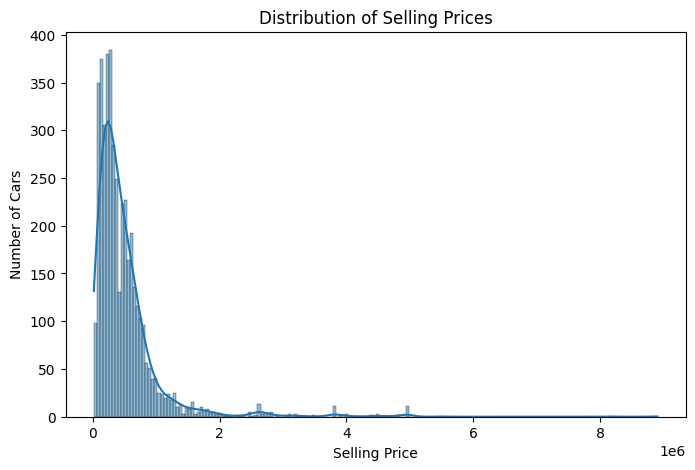

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

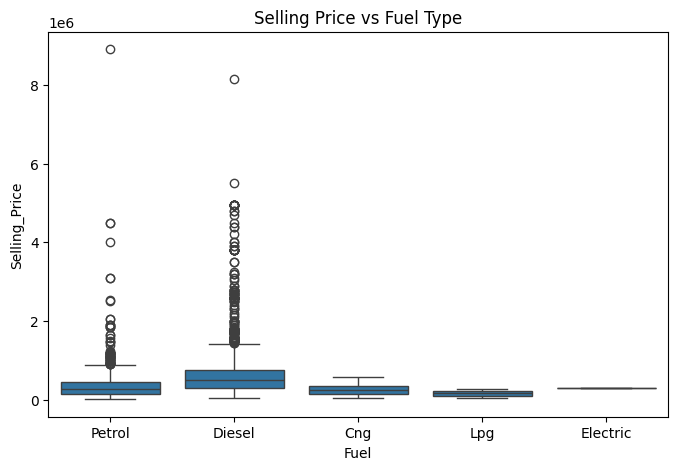

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Fuel', y='Selling_Price', data=df)

plt.title('Selling Price vs Fuel Type')

plt.show()

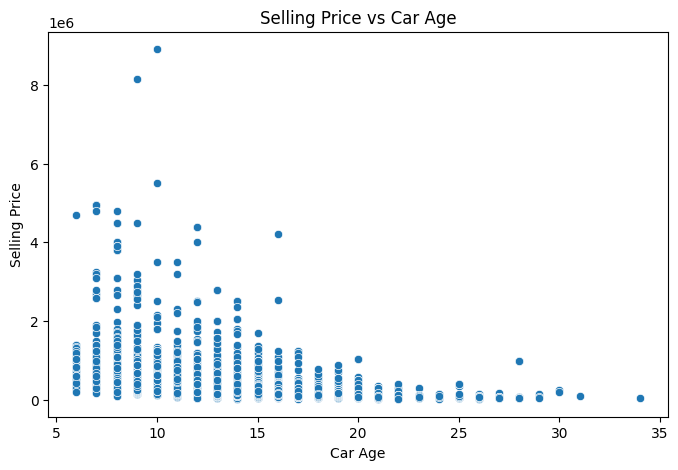

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Selling Price')

plt.show()

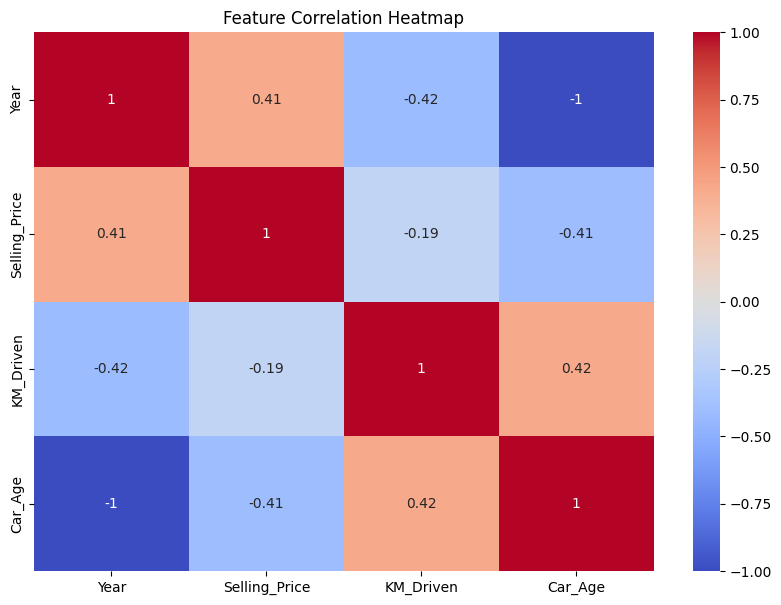

In [30]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation Heatmap')

plt.show()

In [36]:
X = df[
    [

        'Fuel',
        'Seller_Type',
        'Transmission',
        'Owner',
        'Car_Age',
        'Brand'
    ]
]

y = df['Selling_Price']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3472, 6)
Testing data: (868, 6)


In [38]:
categorical_features = [
    'Fuel',
    'Seller_Type',
    'Transmission',
    'Brand'
]

numeric_features = [
    'Present_Price',
    'Kms_Driven',
    'Owner',
    'Car_Age'
]

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 1. Update categorical features to include 'Owner'
categorical_features = ['Fuel', 'Seller_Type', 'Transmission', 'Brand', 'Owner']

# 2. Re-create the preprocessor with the updated categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# 3. Create and fit the pipeline
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
print("Model trained and predictions generated successfully!")

Model trained and predictions generated successfully!


In [43]:
mae_linear = mean_absolute_error(y_test, linear_pred)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

r2_linear = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression
MAE: 186242.35921691888
RMSE: 381021.3442148454
R2 Score: 0.524274572698526


In [44]:
rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [45]:
mae_rf = mean_absolute_error(y_test, rf_pred)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

r2_rf = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
MAE: 123362.6126029528
RMSE: 277852.69866186474
R2 Score: 0.7470195308192933


In [46]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_linear, mae_rf],
    'RMSE': [rmse_linear, rmse_rf],
    'R2 Score': [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,186242.359217,381021.344215,0.524275
1,Random Forest,123362.612603,277852.698662,0.747020


In [47]:
rf = rf_model.named_steps['model']
preprocessor_fitted = rf_model.named_steps['preprocessor']

feature_names = preprocessor_fitted.get_feature_names_out()

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
43,remainder__Car_Age,0.262020
8,cat__Transmission_Automatic,0.152972
9,cat__Transmission_Manual,0.152450
1,cat__Fuel_Diesel,0.103013
28,cat__Brand_Mercedes-Benz,0.067812
12,cat__Brand_BMW,0.053472
35,cat__Brand_Toyota,0.028210
11,cat__Brand_Audi,0.023590
24,cat__Brand_Land,0.022487
5,cat__Seller_Type_Dealer,0.020433


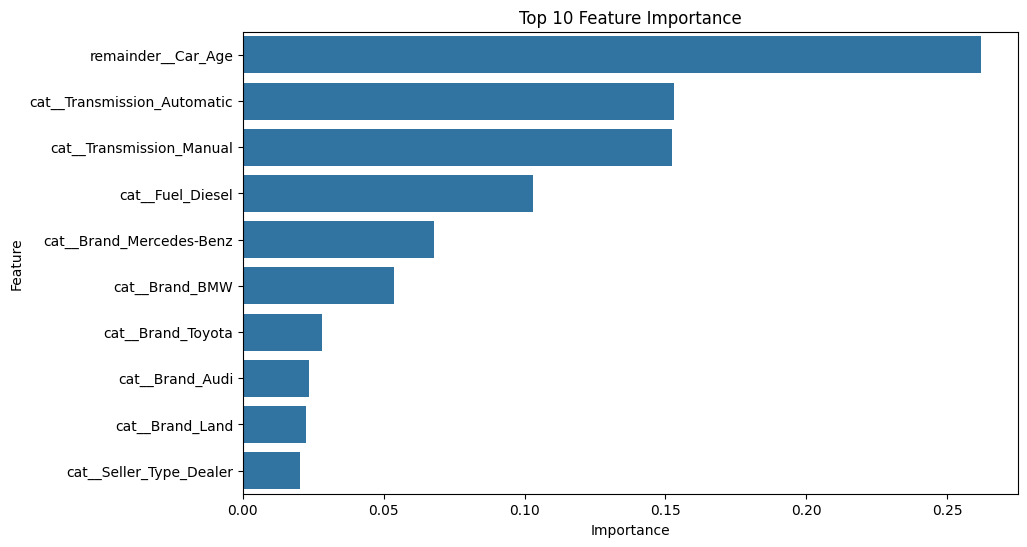

In [48]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Feature Importance')

plt.show()